# Gradient Descent z autograd

In [2]:
import torch
import torch.nn as nn
from tqdm import tqdm

In [3]:
x = torch.randn((2,3), dtype=torch.float32)
print(f"x: {x}")
noise = torch.rand((2,3))
print(f"noise: {noise}")

x: tensor([[ 1.0423,  1.1890, -0.2523],
        [-0.0443,  0.7175, -0.5365]])
noise: tensor([[0.2444, 0.6041, 0.0596],
        [0.0705, 0.1962, 0.5721]])


In [4]:
y = 2 * x + 1 + noise
y

tensor([[3.3289, 3.9822, 0.5551],
        [0.9818, 2.6312, 0.4990]])

In [5]:
loss_fn = nn.MSELoss()

In [9]:
n_epoch = 1000
b = torch.randn(1, dtype=torch.float32, requires_grad=True)
w = torch.randn(1, dtype=torch.float32, requires_grad=True)
losses = []

for epoch in tqdm(range(n_epoch)):

    y_hat = b + w * x
    loss = loss_fn(y_hat, y)
    losses.append(loss.item())

    loss.backward()

    with torch.inference_mode():
        grad_b = b.grad
        grad_w = w.grad
        if grad_b is None or grad_w is None:
            continue

        b -= grad_b * 0.01
        w -= grad_w * 0.01

        grad_b.zero_()
        grad_w.zero_()

    if epoch % 100 == 0:
        print(f"epoch: {epoch}, loss: {loss}")

print(f"b: {b}, w: {w}")


 77%|███████▋  | 774/1000 [00:00<00:00, 4093.17it/s]

epoch: 0, loss: 2.422595739364624
epoch: 100, loss: 0.259686678647995
epoch: 200, loss: 0.09301746636629105
epoch: 300, loss: 0.05720872804522514
epoch: 400, loss: 0.048973023891448975
epoch: 500, loss: 0.047074269503355026
epoch: 600, loss: 0.04663646221160889
epoch: 700, loss: 0.04653551056981087


100%|██████████| 1000/1000 [00:00<00:00, 4227.66it/s]

epoch: 800, loss: 0.046512242406606674
epoch: 900, loss: 0.046506863087415695
b: tensor([1.2684], requires_grad=True), w: tensor([2.0650], requires_grad=True)


In [7]:
import matplotlib.pyplot as plt

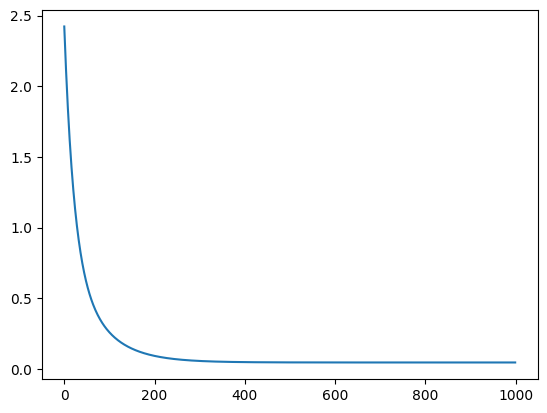

In [10]:
plt.plot(losses)
plt.show()